In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
SAFE_FOLDER = r"C:\Users\karth\Desktop\GeoSentinel-AI\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"

safe_path = Path(SAFE_FOLDER)

print("SAFE Folder Found:", safe_path.exists())

SAFE Folder Found: True


In [3]:
band_files = {}

for file in safe_path.rglob("*.jp2"):

    name = file.name

    if "B02_10m" in name:
        band_files["B02"] = file

    elif "B03_10m" in name:
        band_files["B03"] = file

    elif "B04_10m" in name:
        band_files["B04"] = file

    elif "B08_10m" in name:
        band_files["B08"] = file

    elif "B11_20m" in name:
        band_files["B11"] = file

    elif "B12_20m" in name:
        band_files["B12"] = file

band_files

{'B02': WindowsPath('C:/Users/karth/Desktop/GeoSentinel-AI/data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE/GRANULE/L2A_T43QHV_A048236_20260601T051356/IMG_DATA/R10m/T43QHV_20260601T050649_B02_10m.jp2'),
 'B03': WindowsPath('C:/Users/karth/Desktop/GeoSentinel-AI/data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE/GRANULE/L2A_T43QHV_A048236_20260601T051356/IMG_DATA/R10m/T43QHV_20260601T050649_B03_10m.jp2'),
 'B04': WindowsPath('C:/Users/karth/Desktop/GeoSentinel-AI/data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE/GRANULE/L2A_T43QHV_A048236_20260601T051356/IMG_DATA/R10m/T43QHV_20260601T050649_B04_10m.jp2'),
 'B08': WindowsPath('C:/Users/karth/Desktop/GeoSentinel-AI/data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE/GRANULE/L2A_T43QHV_A048236_20260601T051356/IMG_DATA/R10m/T43QHV_20260601T050649_B08_10m.jp2'),
 'B11': WindowsPath('C:/Users/karth/Desktop/GeoSentinel-

In [4]:
with rasterio.open(band_files["B02"]) as src:
    blue = src.read(1)

with rasterio.open(band_files["B03"]) as src:
    green = src.read(1)

with rasterio.open(band_files["B04"]) as src:
    red = src.read(1)

with rasterio.open(band_files["B08"]) as src:
    nir = src.read(1)

print("Loaded 10m bands")

Loaded 10m bands


In [5]:
with rasterio.open(band_files["B04"]) as src:

    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)

CRS: None
Width: 10980
Height: 10980
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=799980.0, bottom=1890240.0, right=909780.0, top=2000040.0)


In [6]:
rgb = np.dstack((red, green, blue))

rgb = rgb.astype(np.float32)

rgb /= np.percentile(rgb, 98)

rgb = np.clip(rgb, 0, 1)

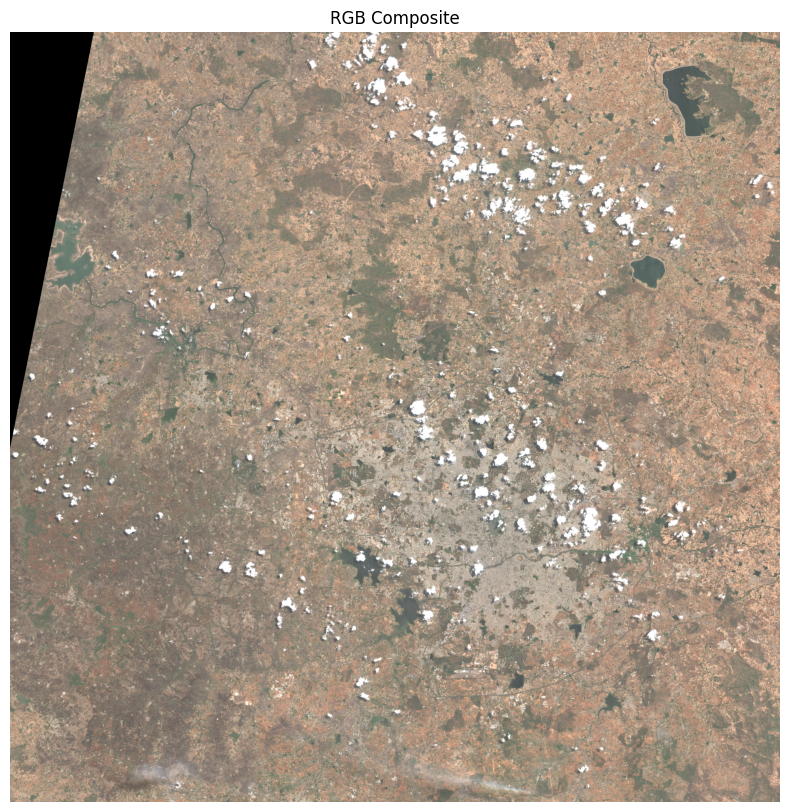

In [7]:
plt.figure(figsize=(10,10))

plt.imshow(rgb)

plt.title("RGB Composite")

plt.axis("off")

plt.show()

In [8]:
plt.figure(figsize=(10,10))

plt.imshow(rgb)

plt.axis("off")

plt.savefig(
    "../data/processed/rgb_composite.png",
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

print("Saved rgb_composite.png")

Saved rgb_composite.png


In [9]:
false_color = np.dstack((nir, red, green))

false_color = false_color.astype(np.float32)

false_color /= np.percentile(false_color, 98)

false_color = np.clip(false_color, 0, 1)

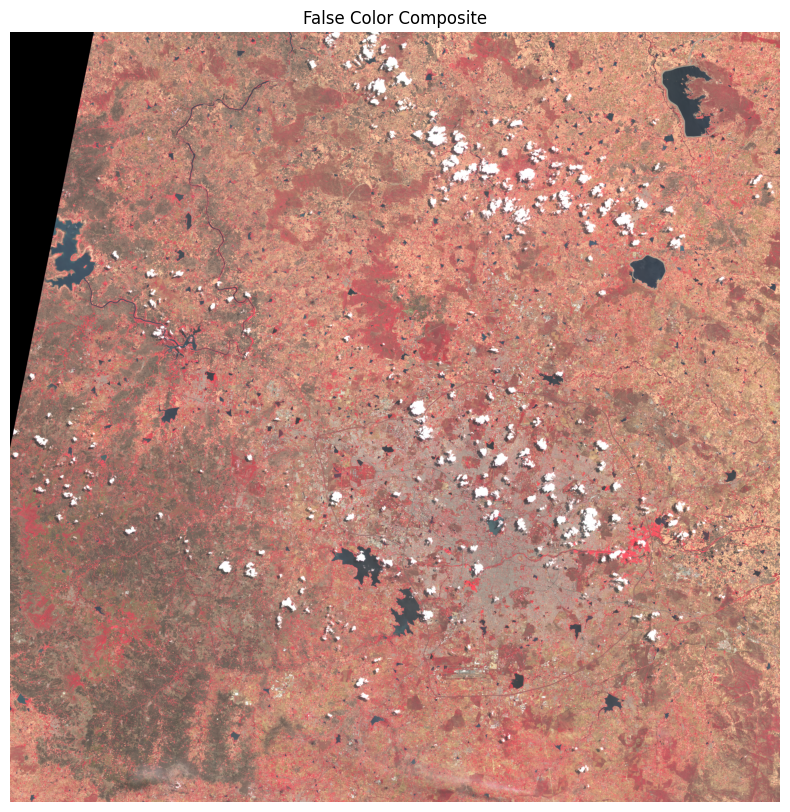

In [10]:
plt.figure(figsize=(10,10))

plt.imshow(false_color)

plt.title("False Color Composite")

plt.axis("off")

plt.show()

In [11]:
plt.figure(figsize=(10,10))

plt.imshow(false_color)

plt.axis("off")

plt.savefig(
    "../data/processed/false_color_composite.png",
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

print("Saved false_color_composite.png")

Saved false_color_composite.png


In [12]:
stats = pd.DataFrame({

    "Band": ["B02","B03","B04","B08"],

    "Min": [
        blue.min(),
        green.min(),
        red.min(),
        nir.min()
    ],

    "Max": [
        blue.max(),
        green.max(),
        red.max(),
        nir.max()
    ],

    "Mean": [
        blue.mean(),
        green.mean(),
        red.mean(),
        nir.mean()
    ],

    "Std": [
        blue.std(),
        green.std(),
        red.std(),
        nir.std()
    ]
})

stats

,Band,Min,Max,Mean,Std
0,B02,0,21664,2055.242504,874.286713
1,B03,0,20180,2319.282684,860.869788
2,B04,0,18949,2575.938680,932.672365
3,B08,0,17787,3582.337670,1091.134132


In [13]:
stats.to_csv(
    "../data/processed/band_statistics.csv",
    index=False
)

print("Saved band_statistics.csv")

Saved band_statistics.csv


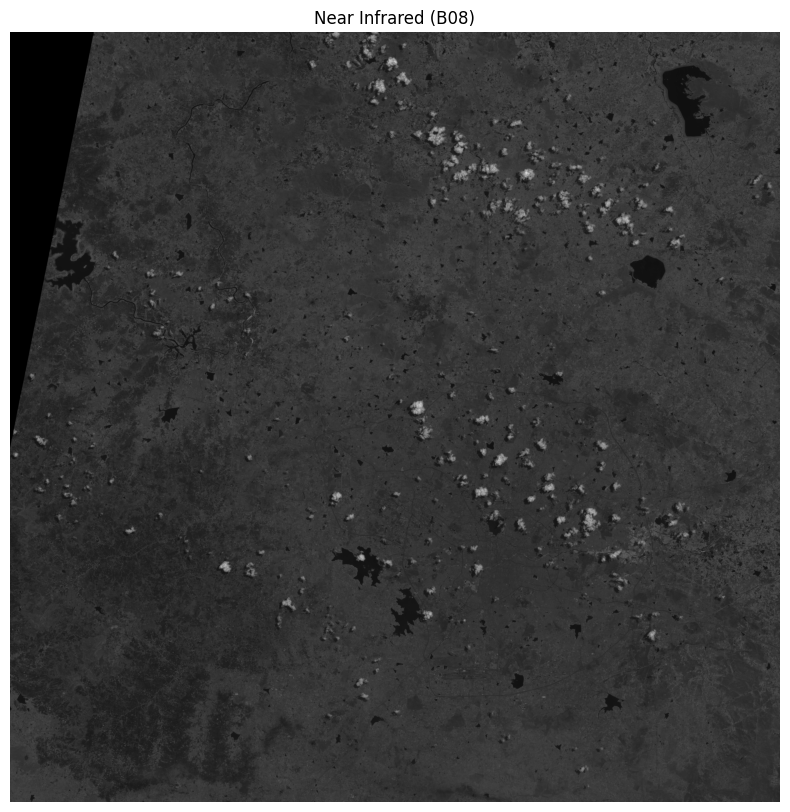

In [14]:
plt.figure(figsize=(10,10))

plt.imshow(nir, cmap="gray")

plt.title("Near Infrared (B08)")

plt.axis("off")

plt.show()

In [15]:
plt.figure(figsize=(10,10))

plt.imshow(nir, cmap="gray")

plt.axis("off")

plt.savefig(
    "../data/processed/nir_band.png",
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

print("Saved nir_band.png")

Saved nir_band.png


In [16]:
print("="*50)

print("Day 12 Completed Successfully")

print("="*50)

print("Generated Files:")

print("1. rgb_composite.png")
print("2. false_color_composite.png")
print("3. nir_band.png")
print("4. band_statistics.csv")

Day 12 Completed Successfully
Generated Files:
1. rgb_composite.png
2. false_color_composite.png
3. nir_band.png
4. band_statistics.csv
